In [1]:
import torch
from torch import nn
import numpy
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Kullanılan cihaz: {device}")


Kullanılan cihaz: cuda


In [2]:
!unzip -q bottle101.zip -d data/

# Zip dosyasını silerek hafızada yer aç
!rm bottle101.zip

In [3]:
def check_data(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"Number of directories {len(dirnames)} and {len(filenames)} images in {dirpath}")

In [4]:
from pathlib import Path

In [5]:
data_path = Path("data/")
image_path = data_path / "bottle101"

In [6]:
check_data(dir_path = image_path)

Number of directories 3 and 0 images in data/bottle101
Number of directories 0 and 139 images in data/bottle101/HalfWaterLevel
Number of directories 0 and 39 images in data/bottle101/Overflowing
Number of directories 0 and 308 images in data/bottle101/FullWaterLevel


In [7]:
import random
from PIL import Image

random.seed(42)

image_path_list = list(image_path.rglob("*.jpeg"))

random_image_path = random.choice(image_path_list)

img = Image.open(random_image_path)

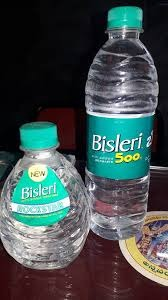

In [8]:
img

# Transform Step

In [9]:
from torchvision import transforms

In [10]:
data_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Train-Test Split

In [11]:
from torchvision import datasets

In [12]:
full_dataset = datasets.ImageFolder(
    root=image_path,
    transform=data_transform
)

In [13]:
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

In [14]:
train_size, test_size

(388, 98)

In [15]:
from torch.utils.data import random_split

In [16]:
random.seed(42)
train_data, test_data = random_split(
    dataset=full_dataset,
    lengths=[train_size, test_size])

In [17]:
len(train_data), len(test_data)

(388, 98)

In [18]:
class_names = full_dataset.classes

In [19]:
class_names

['FullWaterLevel', 'HalfWaterLevel', 'Overflowing']

In [20]:
from collections import Counter
class_counts = Counter(full_dataset.targets)
for idx, name in enumerate(class_names):
    print(f"{name}: {class_counts[idx]} örnek")


FullWaterLevel: 308 örnek
HalfWaterLevel: 139 örnek
Overflowing: 39 örnek


# DataLoader

In [21]:
from torch.utils.data.dataloader import DataLoader

In [22]:
BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataloader = DataLoader(
    dataset=train_data,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

test_dataloader = DataLoader(
    dataset=test_data,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)


# CNN Architecture

In [23]:
class CNNArchitecture(nn.Module):
    def __init__(self):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block_3 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block_4 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block_5 = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier =nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=512 * 7 * 7, out_features = 4096),
            nn.ReLU(),
            nn.Dropout(),

            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(),
            nn.Dropout(),

            nn.Linear(in_features=4096, out_features=len(class_names))
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.block_4(x)
        x = self.block_5(x)
        x = self.classifier(x)
        return x

In [24]:
torch.manual_seed(42)
model = CNNArchitecture().to(device)


# CNN Deep Dive

In [25]:
x = torch.randn(size = [1, 3, 224, 224])
print("Input : ", x.shape)

# 1.Block:
block1 = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
    nn.MaxPool2d(kernel_size=2, stride=2))

block2 = nn.Sequential(
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

block3 = nn.Sequential(
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

block4 = nn.Sequential(
    nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

block5 = nn.Sequential(
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

x = block1(x)
print("Shape of image after block 1: " , x.shape)

x = block2(x)
print("Shape of image after block 2: " , x.shape)

x = block3(x)
print("Shape of image after block 3: " , x.shape)

x = block4(x)
print("Shape of image after block 4: " , x.shape)

x = block5(x)
print("Shape of image after block 5: " , x.shape)

Input :  torch.Size([1, 3, 224, 224])
Shape of image after block 1:  torch.Size([1, 64, 112, 112])
Shape of image after block 2:  torch.Size([1, 128, 56, 56])
Shape of image after block 3:  torch.Size([1, 256, 28, 28])
Shape of image after block 4:  torch.Size([1, 512, 14, 14])
Shape of image after block 5:  torch.Size([1, 512, 7, 7])


Buradan da anlaşıldığı üzere 512 * 7 * 7 olarak Lineer katmana giriş yapılacak.

In [26]:
!pip install torchinfo

In [27]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
CNNArchitecture                          --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       1,792
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       36,928
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-6                       73,856
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       147,584
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
├─Sequential: 1-3                        --
│    └─Conv2d: 2-11                      295,168
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      590,080
│    └─ReLU: 2-14                        --
│    └─Conv2d: 2-15                      590,080
│    └─ReLU: 2-16                        --
│    └─Conv2d: 2-17                     

In [28]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_pred, y_true).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [29]:
from tqdm.auto import tqdm

In [30]:
def train_step(model: torch.nn.Module,
          dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          acc_fn):
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(tqdm(dataloader, desc="Eğitim İlerilemesi")):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += acc_fn(y, y_pred.argmax(dim = 1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc


In [31]:
def test_step(model: torch.nn.Module,
         dataloader: torch.utils.data.DataLoader,
         loss_fn: torch.nn.Module,
         acc_fn):

    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for X, y in tqdm(dataloader, desc="Test İlerlemesi"):
            X, y = X.to(device), y.to(device)
            y_pred = model(X)

            loss = loss_fn(y_pred, y)
            test_loss += loss.item()
            test_acc += acc_fn(y, y_pred.argmax(dim = 1))

        test_loss /= len(dataloader)
        test_acc /= len(dataloader)

    return test_loss, test_acc


In [32]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          acc_fn,
          epochs):

    results = {
        "train_loss" : [],
        "test_loss" : [],
        "train_acc" : [],
        "test_acc" : []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           acc_fn=acc_fn)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        acc_fn=acc_fn)
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results

In [33]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001)

In [34]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 10

model_results = train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    acc_fn=calculate_accuracy,
    epochs=epochs
)

Eğitim İlerilemesi:   0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test İlerlemesi:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9536 | train_acc: 61.0577 | test_loss: 0.8844 | test_acc: 55.4688


Eğitim İlerilemesi:   0%|          | 0/13 [00:00<?, ?it/s]

...

Test İlerlemesi:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 9 | train_loss: 0.8782 | train_acc: 63.9423 | test_loss: 0.8705 | test_acc: 55.4688


Eğitim İlerilemesi:   0%|          | 0/13 [00:00<?, ?it/s]

Test İlerlemesi:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 10 | train_loss: 0.8803 | train_acc: 62.2596 | test_loss: 0.8923 | test_acc: 55.4688


In [35]:
import matplotlib.pyplot as plt
def plt_curves(results):
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]
    train_acc = results["train_acc"]
    test_acc = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(12,6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label = 'Train Loss')
    plt.plot(epochs, test_loss, label = 'Test Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label = 'Train Accuracy')
    plt.plot(epochs, test_acc, label = 'Test Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

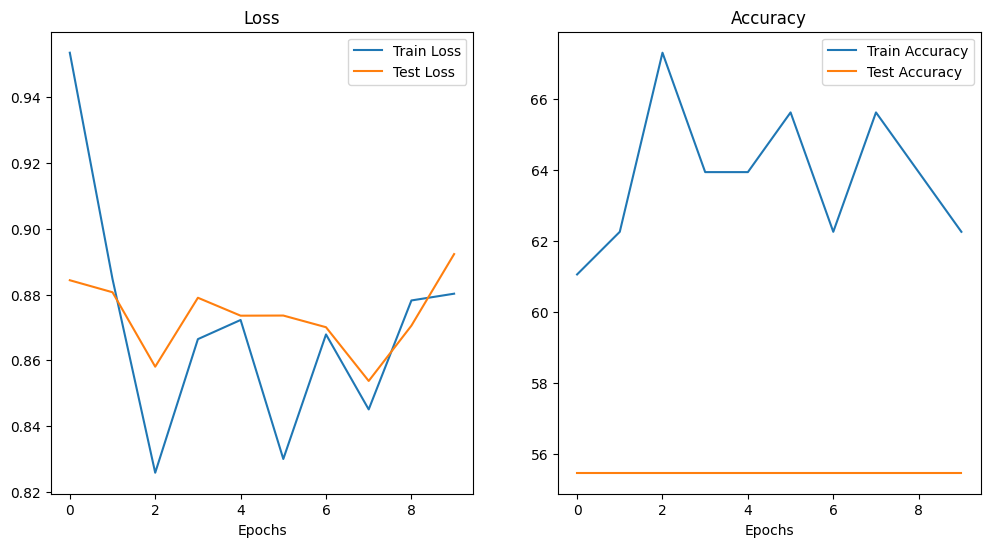

In [36]:
plt_curves(model_results)

In [37]:
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()

    plt.figure(figsize=(6, 6))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0).to(device)
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute (CPU'ya geri al)
            img_show = img.permute(1, 2, 0).cpu()

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()


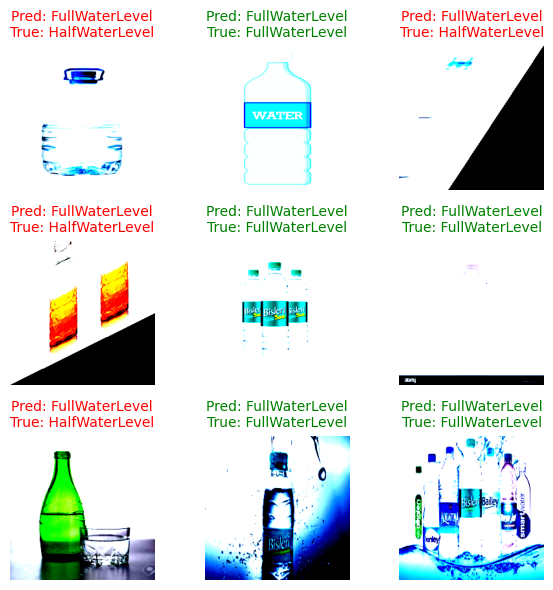

In [40]:
show_random_predictions(model, test_data, class_names)